# Capital Market Line (CML)
菲林格尔、飞沃科技、天普股份 月度数据，2025-01 ~ 2026-03

In [1]:
import scipy.optimize as opt
import atrader as at
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. 获取收盘价数据并计算月度收益率

In [2]:
poforlio = ["sse.603226", "szse.301232", "sse.605255"]
close_data = at.get_kdata(
    poforlio,
    "month",
    fre_num=1,
    begin_date="2025-01-01",
    end_date="2026-03-31",
    fill_up=True,
    df=True,
)["close"]
close_data = pd.DataFrame(np.array(close_data).reshape(3, -1)).T
returns = close_data.iloc[1:, :] / close_data.shift(1).iloc[1:, :] - 1
print("5 head of returns:\n", returns.head())

5 head of returns:
          0        1        2
1  0.21996  0.09050  0.11945
2  0.00455 -0.04888  0.18878
3  0.08748  0.03586 -0.02589
4  0.14008  0.07923  0.16775
5  0.62652  0.09515 -0.01062


## 2. 计算均值与协方差矩阵

In [3]:
means = returns.mean()
print("mean returns:\n", means)
cov = returns.cov()
print("covariance matrix:\n", cov)

mean returns:
 0    0.16770
1    0.21201
2    0.23277
dtype: float64
covariance matrix:
          0        1        2
0  0.06253 -0.05855  0.04633
1 -0.05855  0.25504  0.03394
2  0.04633  0.03394  0.22164


## 3. 有效前沿（Efficient Frontier）

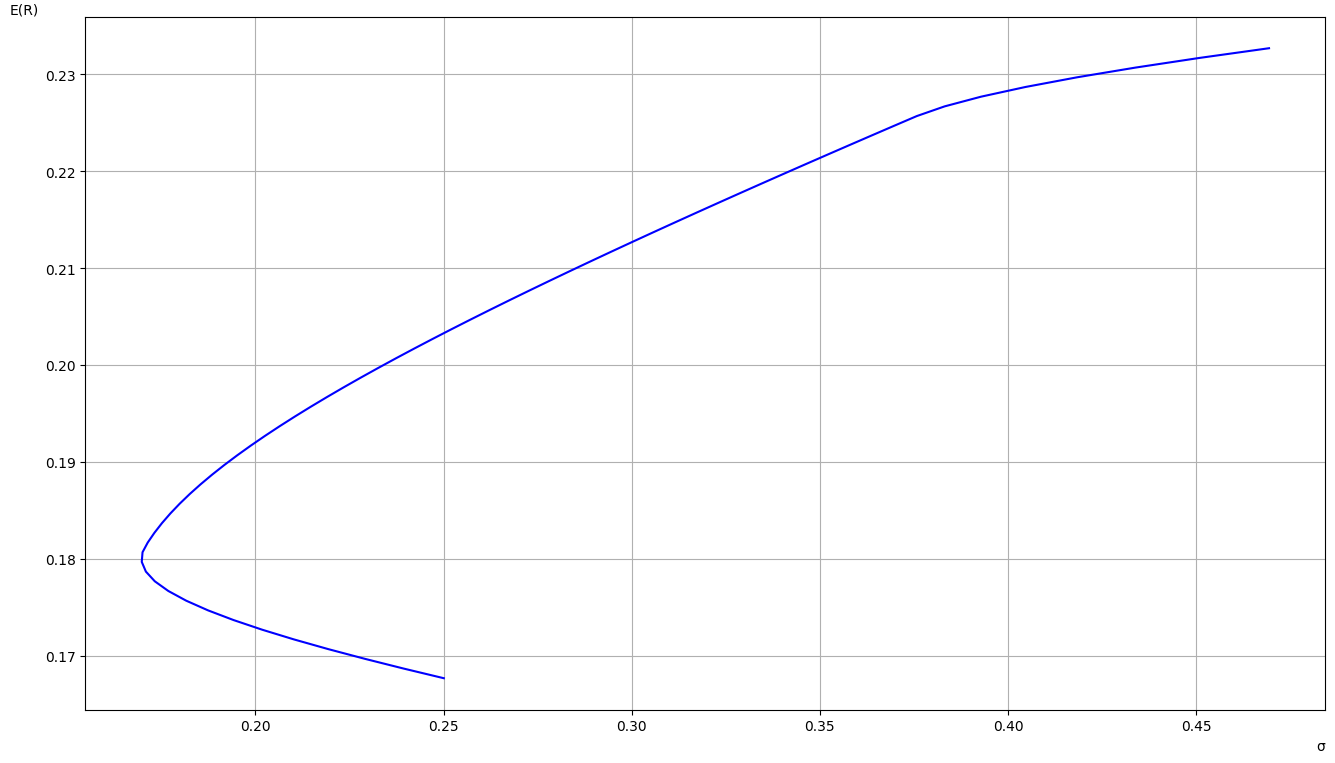

In [4]:
def poforlioVar(w):
    return np.dot(w.T, np.dot(cov, w))

mean = np.arange(min(means), max(means), 0.001, dtype=float)
std = []
w = [1 / len(means)] * len(means)
bounds = [(0, None)] * len(means)

for target in mean:
    constrain = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w, t=target: np.dot(w.T, means) - t},
    )
    result = opt.minimize(poforlioVar, w, constraints=constrain, bounds=bounds)
    std.append(np.sqrt(result.fun))

plt.figure(figsize=(16, 9))
plt.plot(std, mean, color="blue")
plt.xlabel("σ", loc="right")
plt.ylabel("E(R)", loc="top", rotation=0)
plt.grid()

## 4. 最小方差组合（Minimum Variance Portfolio）

Min risk portfolio:
 [7.21438765e-01 2.78561235e-01 1.32095379e-17]
Min risk portfolio standard deviation: 0.16972206482489863
Min risk portfolio mean return: 0.18004218341053127


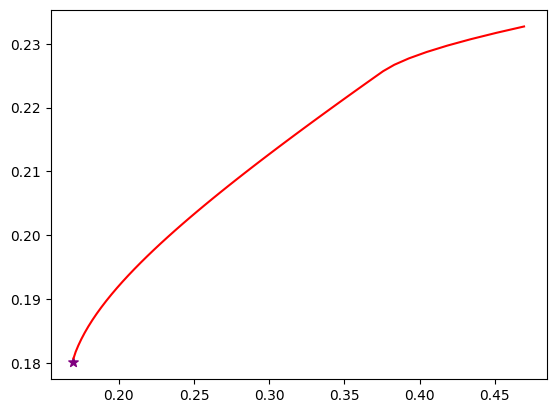

In [5]:
constrain = ({"type": "eq", "fun": lambda w: np.sum(w) - 1})
result = opt.minimize(poforlioVar, w, constraints=constrain, bounds=bounds)
std_min = np.sqrt(result.fun)
mean_min = np.dot(result.x.T, means)
print("Min risk portfolio:\n", result.x)
print("Min risk portfolio standard deviation:", std_min)
print("Min risk portfolio mean return:", mean_min)

plt.scatter(std_min, mean_min, color="purple", marker="*", s=50)
plt.plot(
    pd.Series(std)[mean >= mean_min],
    pd.Series(mean)[mean >= mean_min],
    color="red",
    label="Efficient Frontier",
)

## 5. 市场组合与资本市场线（Capital Market Line）

Market portfolio:
 [0.70470528 0.29529472 0.        ]
Market portfolio standard deviation: 0.17
Market portfolio mean return: 0.181


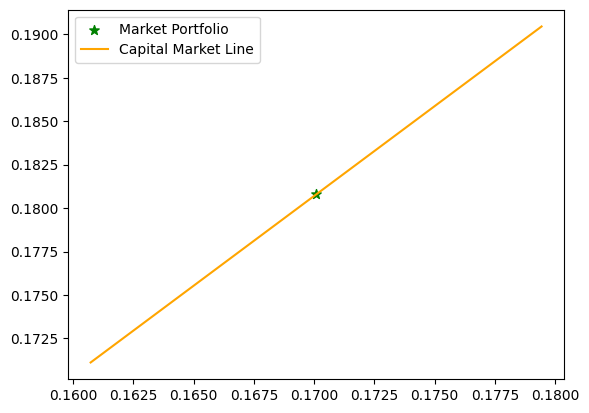

In [6]:
rf = 0.005
w = [1 / len(means)] * len(means)
constrain = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

def min_sharpe(w):
    return -(np.dot(w.T, means) - rf) / np.sqrt(np.dot(w.T, np.dot(cov, w)))

result = opt.minimize(min_sharpe, w, constraints=constrain, bounds=bounds)
sharpe = -result.fun
weights = result.x
std_market = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
mean_market = np.dot(weights.T, means)
print("Market portfolio:\n", weights)
print("Market portfolio standard deviation:", round(std_market, 3))
print("Market portfolio mean return:", round(mean_market, 3))

plt.scatter(std_market, mean_market, color="green", marker="*", s=50, label="Market Portfolio")

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = rf + sharpe * x_vals
plt.plot(x_vals, y_vals, color="orange", label="Capital Market Line")

plt.legend()
plt.show()